# Phase 7: Evaluation

Confusion matrices, ROC-AUC, feature importance for the 6 best models from Phase 6. Figures saved to outputs/figures/.

## Step 0 — Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from pathlib import Path
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', context='notebook')

CWD    = Path.cwd()
ROOT   = CWD if (CWD / 'data').exists() else CWD.parent
df     = pd.read_csv(ROOT / 'data' / 'processed' / 'model_ready.csv')
risk   = pd.read_csv(ROOT / 'data' / 'processed' / 'risk_profile.csv')
MODELS = ROOT / 'outputs' / 'models'
TABLES = ROOT / 'outputs' / 'tables'
FIGS   = ROOT / 'outputs' / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

FACTORS = ['force', 'repetition', 'duration', 'vibration', 'contact_stress', 'posture']
LABELS  = ['Low', 'Medium', 'High']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('models  :', sorted([p.name for p in MODELS.glob('*.pkl')]))

models  : ['best_contact_stress.pkl', 'best_duration.pkl', 'best_force.pkl', 'best_posture.pkl', 'best_repetition.pkl', 'best_vibration.pkl']


## Step 1 — Confusion matrix heatmaps

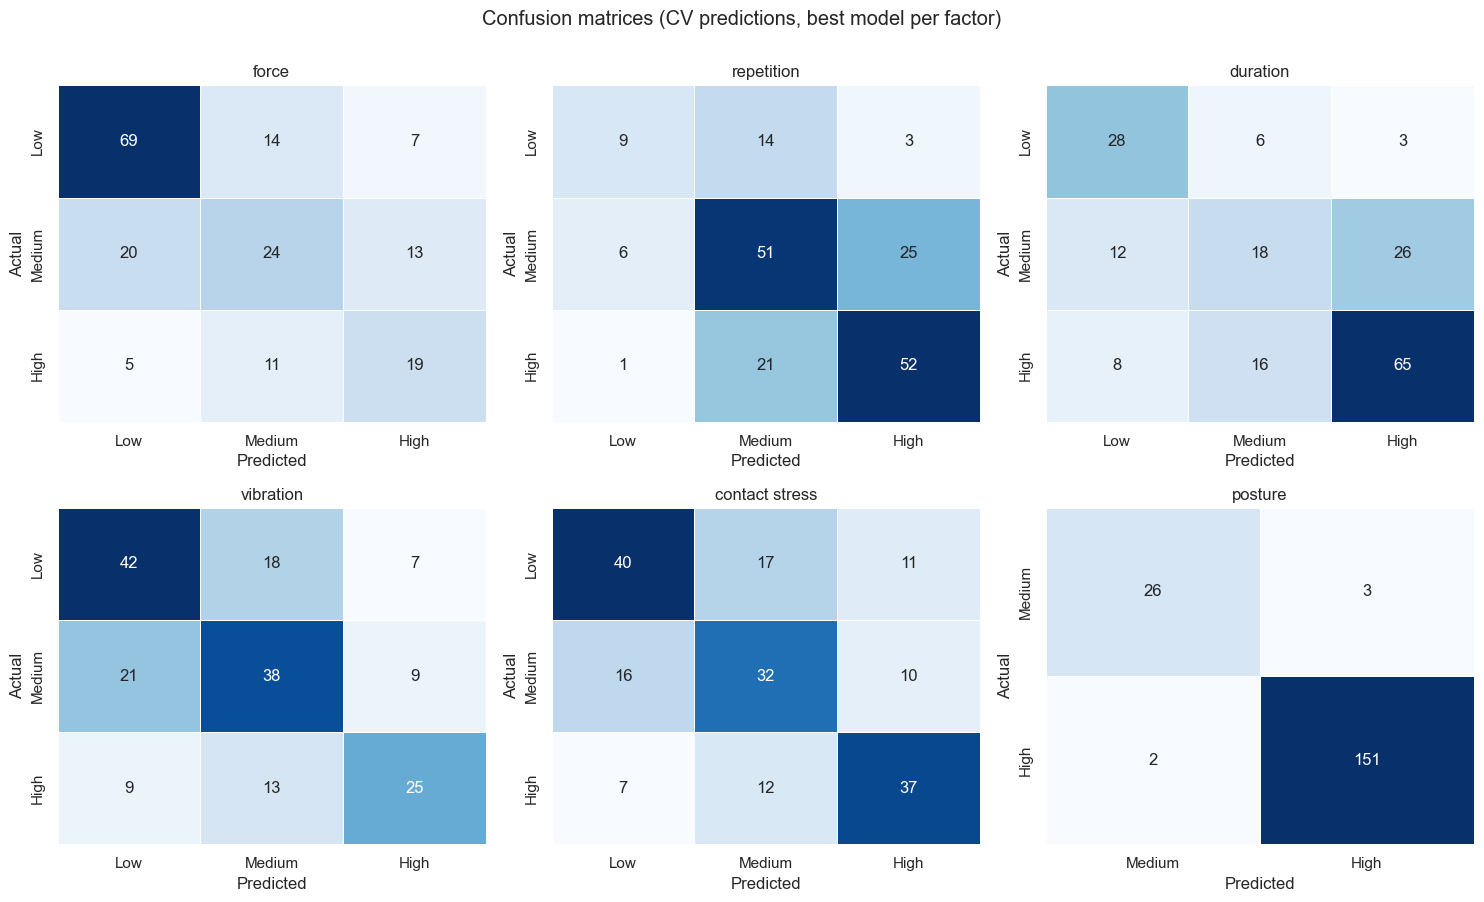

In [2]:
# Plot the Phase-6 saved confusion counts as 6 heatmaps
cm_df = pd.read_csv(TABLES / 'confusion_matrices.csv')

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, factor in zip(axes.flat, FACTORS):
    sub = cm_df[cm_df['target'] == factor]
    pivot = sub.pivot(index='true', columns='predicted', values='count')
    present = [lbl for lbl in LABELS if lbl in pivot.index or lbl in pivot.columns]
    pivot = pivot.reindex(present).reindex(present, axis=1).fillna(0).astype(int)
    sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                linewidths=.5, linecolor='white')
    ax.set_title(factor.replace('_', ' '))
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion matrices (CV predictions, best model per factor)', y=1.00)
plt.tight_layout()
plt.savefig(FIGS / 'confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 2 — Multi-class ROC-AUC (one-vs-rest)

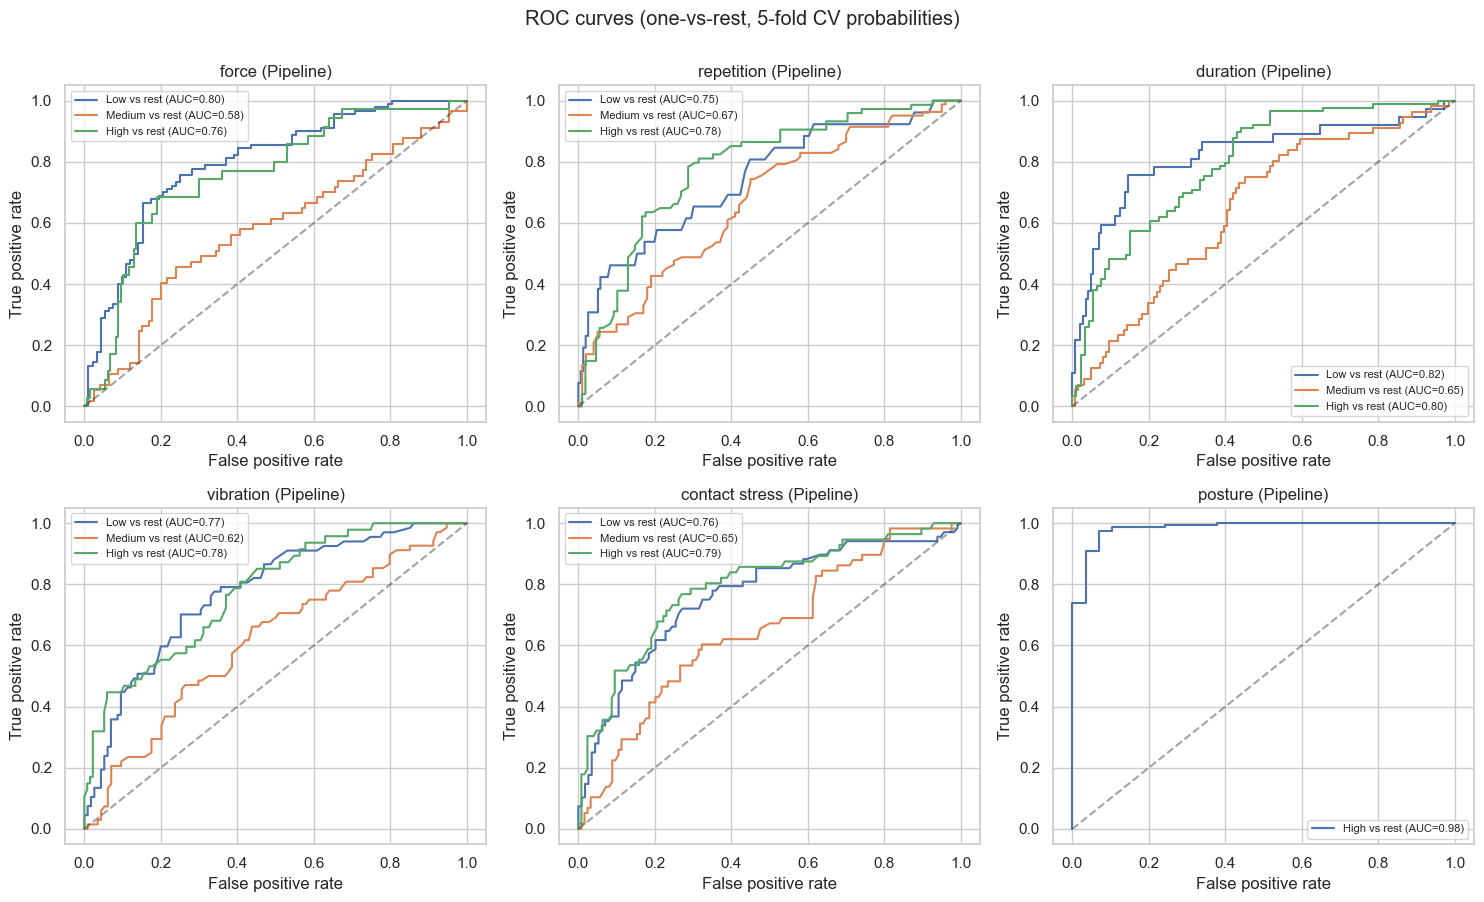

,factor,class,AUC
0,force,Low,0.798
1,force,Medium,0.580
2,force,High,0.760
3,repetition,Low,0.745
4,repetition,Medium,0.669
5,repetition,High,0.782
6,duration,Low,0.822
7,duration,Medium,0.649
8,duration,High,0.797
9,vibration,Low,0.775


In [3]:
# Add the 6 risk codes onto the feature frame
data = df.copy()
for c in ['force_risk_code', 'repetition_risk_code', 'duration_risk_code',
          'vibration_risk_code', 'contact_stress_risk_code', 'posture_risk_code']:
    data[c] = risk[c].values

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
auc_rows = []
for ax, factor in zip(axes.flat, FACTORS):
    bundle  = joblib.load(MODELS / f'best_{factor}.pkl')
    feats   = bundle['features']
    classes = bundle['classes']
    X = data[feats]
    y_raw = data[f'{factor}_risk_code']
    le = LabelEncoder().fit(y_raw)
    y  = le.transform(y_raw)

    # CV predicted probabilities
    proba = cross_val_predict(clone(bundle['model']), X, y,
                              cv=cv, method='predict_proba', n_jobs=-1)
    n_classes = len(classes)

    if n_classes == 2:
        fpr, tpr, _ = roc_curve(y, proba[:, 1])
        a = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{LABELS[classes[1]]} vs rest (AUC={a:.2f})')
        auc_rows.append({'factor': factor, 'class': LABELS[classes[1]], 'AUC': round(a, 3)})
    else:
        y_bin = label_binarize(y, classes=list(range(n_classes)))
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
            a = auc(fpr, tpr)
            ax.plot(fpr, tpr, label=f'{LABELS[classes[i]]} vs rest (AUC={a:.2f})')
            auc_rows.append({'factor': factor, 'class': LABELS[classes[i]], 'AUC': round(a, 3)})

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_xlabel('False positive rate')
    ax.set_ylabel('True positive rate')
    ax.set_title(f'{factor.replace("_"," ")} ({type(bundle["model"]).__name__})')
    ax.legend(fontsize=8)
plt.suptitle('ROC curves (one-vs-rest, 5-fold CV probabilities)', y=1.00)
plt.tight_layout()
plt.savefig(FIGS / 'roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

auc_df = pd.DataFrame(auc_rows)
auc_df.to_csv(TABLES / 'roc_auc.csv', index=False)
auc_df

## Step 3 — Feature importance

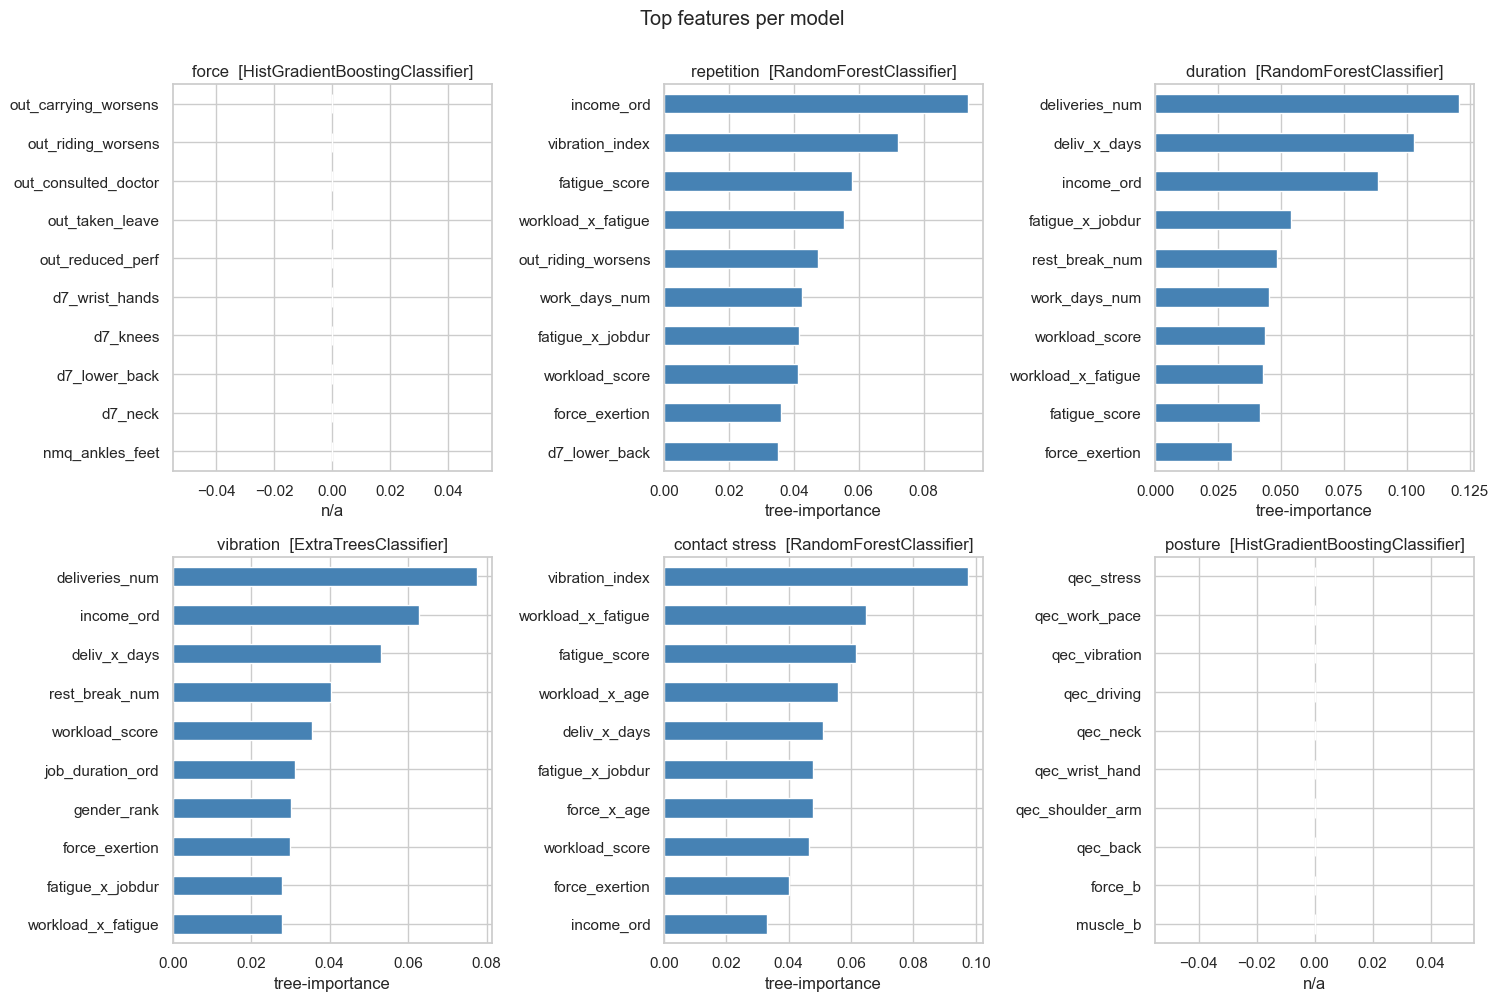

,factor,feature,importance
0,contact_stress,vibration_index,0.0974
1,contact_stress,workload_x_fatigue,0.0649
2,contact_stress,fatigue_score,0.0616
3,duration,deliveries_num,0.1206
4,duration,deliv_x_days,0.1030
5,duration,income_ord,0.0886
6,force,workload_score,0.0000
7,force,fatigue_score,0.0000
8,force,age_ord,0.0000
9,posture,workload_score,0.0000


In [4]:
# Tree models -> feature_importances_, LogReg -> mean(|coef_|),
# Stacking -> average across its base estimators that expose one.
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
imp_rows = []
for ax, factor in zip(axes.flat, FACTORS):
    bundle = joblib.load(MODELS / f'best_{factor}.pkl')
    pipe   = bundle['model']
    feats  = bundle['features']

    # Unwrap the SMOTE pipeline so we can reach the actual classifier
    model = pipe.named_steps['clf'] if hasattr(pipe, 'named_steps') else pipe

    if hasattr(model, 'feature_importances_'):
        imp = pd.Series(model.feature_importances_, index=feats)
        kind = 'tree-importance'
    elif hasattr(model, 'coef_'):
        imp = pd.Series(np.abs(model.coef_).mean(axis=0), index=feats)
        kind = 'mean(|coef|)'
    elif hasattr(model, 'named_estimators_'):
        # Stacking: average importance from base estimators that have it
        parts = []
        for est in model.named_estimators_.values():
            if hasattr(est, 'feature_importances_'):
                parts.append(pd.Series(est.feature_importances_, index=feats))
            elif hasattr(est, 'coef_'):
                parts.append(pd.Series(np.abs(est.coef_).mean(axis=0), index=feats))
        imp = (pd.concat(parts, axis=1).mean(axis=1) if parts
               else pd.Series([0.0] * len(feats), index=feats))
        kind = 'stacking avg'
    else:
        imp = pd.Series([0.0] * len(feats), index=feats)
        kind = 'n/a'

    imp = imp.sort_values()
    imp.tail(10).plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{factor.replace("_"," ")}  [{type(model).__name__}]')
    ax.set_xlabel(kind)
    for f, v in imp.items():
        imp_rows.append({'factor': factor, 'feature': f, 'importance': round(float(v), 4)})

plt.suptitle('Top features per model', y=1.00)
plt.tight_layout()
plt.savefig(FIGS / 'feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

imp_df = pd.DataFrame(imp_rows)
imp_df.to_csv(TABLES / 'feature_importance.csv', index=False)
imp_df.groupby('factor').apply(lambda g: g.nlargest(3, 'importance')).reset_index(drop=True)

## Step 4 — Phase 7 summary

In [5]:
# Merge Phase 6 best_models with Phase 7 macro AUC
best = pd.read_csv(TABLES / 'best_models.csv')[['target', 'best_model', 'cv_accuracy', 'cv_f1_macro', 'overfit_gap']]
macro_auc = auc_df.groupby('factor')['AUC'].mean().round(3).reset_index().rename(columns={'factor': 'target', 'AUC': 'macro_auc'})
summary = best.merge(macro_auc, on='target', how='left')
summary['overfit_flag'] = summary['overfit_gap'] > 0.15
summary.to_csv(TABLES / 'phase7_summary.csv', index=False)
summary

,target,best_model,cv_accuracy,cv_f1_macro,overfit_gap,macro_auc,overfit_flag
0,force,HistGBM,0.616,0.565,0.384,0.713,True
1,repetition,RandomForest,0.615,0.571,0.385,0.732,True
2,duration,RandomForest,0.610,0.580,0.314,0.756,True
3,vibration,ExtraTrees,0.576,0.573,0.424,0.723,True
4,contact_stress,RandomForest,0.599,0.589,0.401,0.735,True
5,posture,HistGBM,0.972,0.949,0.028,0.984,False
